
# Part 2.2 — Numerical cross-check: direct optimisation vs. closed-form projection

**Thesis reference:** Chapter 6 (numerical algorithms, unconstrained case recovered from the constrained one), Chapter 7 — Experiment 4 (continued).

Chapter 5's closed-form result -- the constrained optimum is the projection of Merton's unconstrained proportion onto $[a,b]$ -- is convenient, but it is specific to a single risky asset with a box constraint. This notebook validates it against a solver that uses **no** knowledge of that closed form: a direct bounded 1-D numerical maximisation of the certainty-equivalent wealth over $[a,b]$, using only the general closed-form expected-utility formula for an *arbitrary* constant-mix strategy as a black box. Agreement between the two is a genuine algorithmic cross-check -- the two computations share no code path -- and is exactly the kind of check the general BSDE-based or dual-gradient algorithms of Chapter 6 would need to pass in a setting where no closed form is available at all.


In [1]:

import numpy as np
import matplotlib.pyplot as plt

from optiport.continuous.black_scholes import BlackScholesMarket
from optiport.constraints.constrained_black_scholes import ConstrainedBlackScholesMarket
from optiport.constraints.dual_gradient import numerical_constrained_optimum, certainty_equivalent
from optiport.utility import CRRAUtility

plt.rcParams["figure.dpi"] = 110

market = BlackScholesMarket(mu=0.10, sigma=0.20, r=0.02)
T, x0 = 1.0, 100.0



## 1. Certainty-equivalent wealth as a function of $\pi$, and its numerical maximiser

For a fixed box $[a,b]$, we plot the certainty-equivalent wealth $CE(\pi)$ over the whole box, mark the numerically found maximiser, and compare it to the closed-form projected-Merton solution.


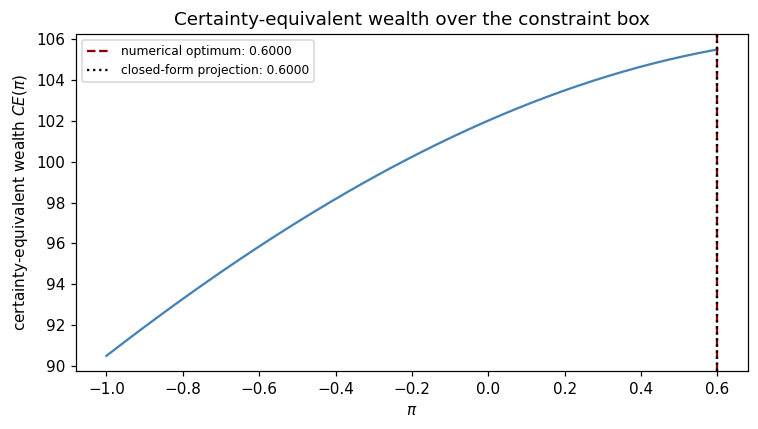

gap: 9.37e-09


In [2]:

alpha = -1.0
utility = CRRAUtility(alpha)
a, b = -1.0, 0.6

pi_grid = np.linspace(a, b, 200)
ce_values = [certainty_equivalent(market, utility, T, x0, pi) for pi in pi_grid]

pi_numerical = numerical_constrained_optimum(market, utility, T, x0, a, b)
cmarket = ConstrainedBlackScholesMarket(market=market, a=a, b=b)
pi_closed_form = cmarket.constrained_optimal_pi(utility)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(pi_grid, ce_values, color="steelblue")
ax.axvline(pi_numerical, color="darkred", linestyle="--", label=f"numerical optimum: {pi_numerical:.4f}")
ax.axvline(pi_closed_form, color="black", linestyle=":", label=f"closed-form projection: {pi_closed_form:.4f}")
ax.set_xlabel(r"$\pi$")
ax.set_ylabel("certainty-equivalent wealth $CE(\\pi)$")
ax.set_title("Certainty-equivalent wealth over the constraint box")
ax.legend(fontsize=8)
fig.tight_layout()
plt.savefig("fig_01_ce_vs_pi.png", bbox_inches="tight")
plt.show()

print(f"gap: {abs(pi_numerical - pi_closed_form):.2e}")



## 2. Agreement across risk aversion levels and constraint sets

We now repeat the comparison across a grid of CRRA parameters and box constraints, covering all three qualitative regimes (binding above, binding below, not binding).


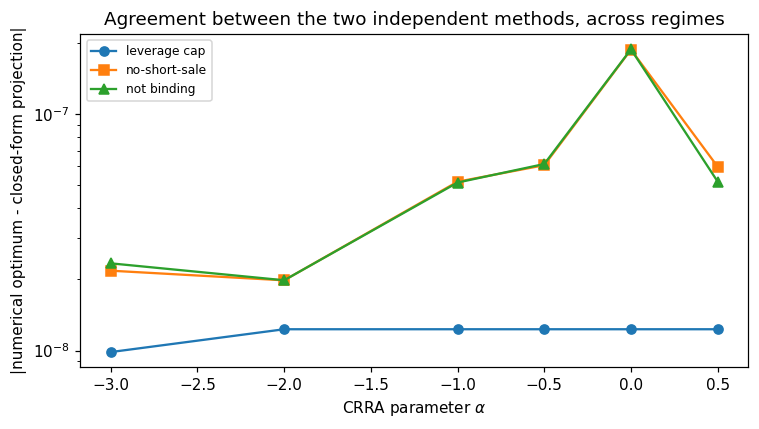

In [3]:

alphas = [-3.0, -2.0, -1.0, -0.5, 0.0, 0.5]
boxes = [(-np.inf, 0.5), (0.0, np.inf), (-10.0, 10.0)]
box_labels = ["leverage cap", "no-short-sale", "not binding"]

fig, ax = plt.subplots(figsize=(7, 4))
markers = ["o", "s", "^"]
for (a, b), label, marker in zip(boxes, box_labels, markers):
    gaps = []
    for alpha in alphas:
        utility = CRRAUtility(alpha)
        cmarket = ConstrainedBlackScholesMarket(market=market, a=a, b=b)
        pi_cf = cmarket.constrained_optimal_pi(utility)
        pi_num = numerical_constrained_optimum(market, utility, T, x0, a, b)
        gaps.append(abs(pi_cf - pi_num))
    ax.semilogy(alphas, np.array(gaps) + 1e-16, marker=marker, label=label)

ax.set_xlabel(r"CRRA parameter $\alpha$")
ax.set_ylabel("|numerical optimum - closed-form projection|")
ax.set_title("Agreement between the two independent methods, across regimes")
ax.legend(fontsize=8)
fig.tight_layout()
plt.savefig("fig_02_agreement_grid.png", bbox_inches="tight")
plt.show()



The gap stays at the numerical-tolerance floor of the bounded 1-D solver (of the order of $10^{-6}$-$10^{-8}$) across every risk-aversion level and every constraint regime, including the log-utility case ($\alpha=0$) and the degenerate non-binding case. This is a meaningful cross-check precisely because the two computations are independent: the closed-form path relies on the projection argument and the auxiliary-market duality of Chapter 5, while the numerical path only ever evaluates the general expected-utility formula and searches the box directly, with no reference to Merton's formula or to the constrained duality theorem at all.



## Conclusion

This closes Experiment 4 (Chapter 7): the constrained duality theory of Chapter 5 is validated three independent ways across this notebook and the previous one -- pathwise coincidence with the auxiliary-market dual FOC, correct qualitative behaviour of the utility loss as the constraint tightens, and now agreement with a numerical optimiser that shares no code with the closed-form solution. Together with Part 1 (Experiments 1-3), this completes the numerical validation programme laid out in Chapter 7 of the thesis for the single-asset, box-constrained case; extending the numerical machinery to higher-dimensional or path-dependent constraints via a full regression-Monte-Carlo BSDE scheme, as outlined in Chapter 6, remains open for a later iteration of this project.
